In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [3]:
HERE = Path.cwd()
soccer_path = HERE.parent / "correlations_skill_luck_decomposition.csv"
us_path = (
    HERE.parents[2]
    / "us_leagues"
    / "skill_luck_decomposition"
    / "skill_luck_decomposition.csv"
)

print("European file:", soccer_path)
print("US file :", us_path)

European file: /Users/adhvik_rayaprolu/Desktop/uiuc/IML_Fall2025/skillvsluck/output/european_soccer_leagues/skill_luck_decomposition/correlations_skill_luck_decomposition.csv
US file : /Users/adhvik_rayaprolu/Desktop/uiuc/IML_Fall2025/skillvsluck/output/us_leagues/skill_luck_decomposition/skill_luck_decomposition.csv


In [4]:
# --- European leagues -------------------------------------------------
euro_df = pd.read_csv(soccer_path)

# make sure season is numeric
euro_df["season"] = pd.to_numeric(euro_df["season"], errors="coerce")

euro_df = euro_df[euro_df["season"] >= 2000].copy()
euro_df["skill_share_pct"] = euro_df["spearman_r_actual"]

# convert from 0–1 to % if needed
if euro_df["skill_share_pct"].max() <= 1.0 + 1e-9:
    euro_df["skill_share_pct"] *= 100.0

euro_df = euro_df[["league", "season", "skill_share_pct"]]

# --- US leagues -------------------------------------------------------
us_df = pd.read_csv(us_path)

# keep only the correlation metric rows
corr_mask = us_df["metric_name"].str.contains("spearman_r", case=False, na=False)
us_corr = us_df[corr_mask].copy()

# ensure season is numeric before filtering
us_corr["season"] = pd.to_numeric(us_corr["season"], errors="coerce")

us_corr = us_corr[us_corr["season"] >= 2000].copy()

# metric_real = actual skill share for that metric
us_corr["skill_share_pct"] = us_corr["metric_real"]

if us_corr["skill_share_pct"].max() <= 1.0 + 1e-9:
    us_corr["skill_share_pct"] *= 100.0

us_corr = us_corr[["league", "season", "skill_share_pct"]]


# --- Combine ----------------------------------------------------------
all_skill = pd.concat([euro_df, us_corr], ignore_index=True)

print(all_skill.dtypes)
print(all_skill.head())

league              object
season               int64
skill_share_pct    float64
dtype: object
       league  season  skill_share_pct
0  Bundesliga    2004        44.698545
1  Bundesliga    2005        43.639231
2  Bundesliga    2006        39.378238
3  Bundesliga    2007        56.438488
4  Bundesliga    2008        46.805252


Saved figure to: /Users/adhvik_rayaprolu/Desktop/uiuc/IML_Fall2025/skillvsluck/output/european_soccer_leagues/skill_luck_decomposition/final_graphs/year_on_year_correlations_skill_luck_share.png


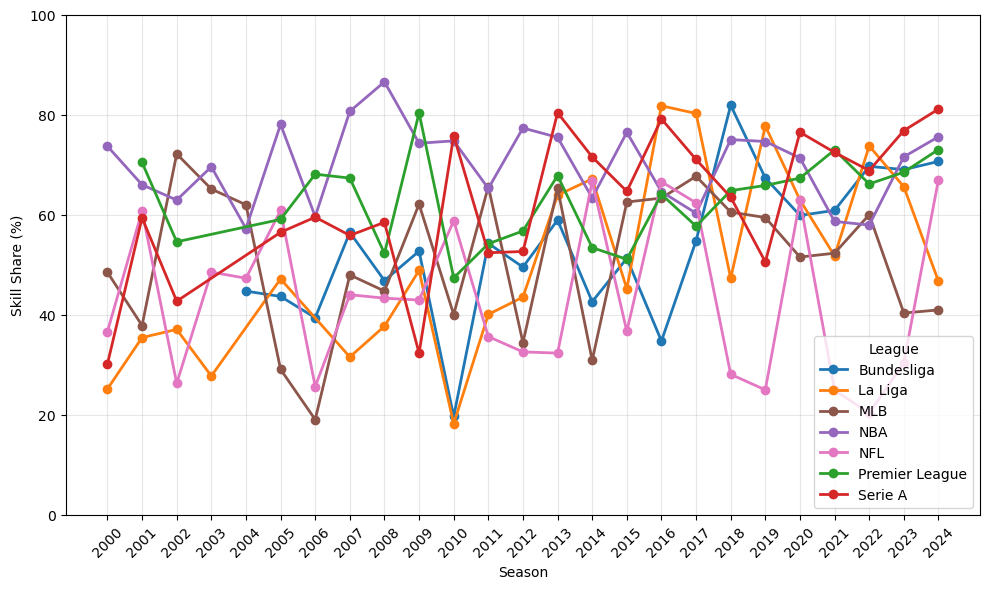

In [6]:
color_map = {
    "Bundesliga": "tab:blue",
    "La Liga": "tab:orange",
    "Premier League": "tab:green",
    "Serie A": "tab:red",
    "NBA": "tab:purple",
    "MLB": "tab:brown",
    "NFL": "tab:pink",
}

fig, ax = plt.subplots(figsize=(10, 6))

for league in sorted(all_skill["league"].unique()):
    sub = all_skill[all_skill["league"] == league].sort_values("season")
    ax.plot(
        sub["season"],
        sub["skill_share_pct"],
        marker="o",
        linewidth=2,
        label=league,
        color=color_map.get(league, None),
    )

ax.set_xlabel("Season")
ax.set_ylabel("Skill Share (%)")
ax.set_xticks(sorted(all_skill["season"].unique()))
ax.set_xticklabels(sorted(all_skill["season"].unique()), rotation=45)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend(title="League", loc="best")

fig.tight_layout()

out_path = HERE / "year_on_year_correlations_skill_luck_share.png"
fig.savefig(out_path, dpi=300)
print(f"Saved figure to: {out_path}")

In [7]:
here = Path.cwd()

euro_upset_path = here.parent / "upset_frequency_skill_luck_decomposition.csv"
us_upset_path   = here.parents[2] / "us_leagues" / "skill_luck_decomposition" / "skill_luck_decomposition.csv"

print("European upset file:", euro_upset_path)
print("US upset file:", us_upset_path)

European upset file: /Users/adhvik_rayaprolu/Desktop/uiuc/IML_Fall2025/skillvsluck/output/european_soccer_leagues/skill_luck_decomposition/upset_frequency_skill_luck_decomposition.csv
US upset file: /Users/adhvik_rayaprolu/Desktop/uiuc/IML_Fall2025/skillvsluck/output/us_leagues/skill_luck_decomposition/skill_luck_decomposition.csv


In [8]:
# ---------- European leagues upset-frequency ----------
euro_upset = pd.read_csv(euro_upset_path)

# ensure numeric season and filter
euro_upset["season"] = pd.to_numeric(euro_upset["season"], errors="coerce")
euro_upset = euro_upset[euro_upset["season"] >= 2000].copy()

# use q_results as the skill share for upset frequency (European data)
euro_upset["skill_share_pct"] = euro_upset["q_results"]

# convert to percent if needed
if euro_upset["skill_share_pct"].max() <= 1.0 + 1e-9:
    euro_upset["skill_share_pct"] *= 100.0

euro_upset = euro_upset[["league", "season", "skill_share_pct"]]

# ---------- US leagues upset-frequency ----------
us_full = pd.read_csv(us_upset_path)

# keep only the upset-frequency metric rows
upset_mask = us_full["metric_name"].str.contains("upset_frequency", case=False, na=False)
us_upset = us_full[upset_mask].copy()

# ensure numeric season and filter
us_upset["season"] = pd.to_numeric(us_upset["season"], errors="coerce")
us_upset = us_upset[us_upset["season"] >= 2000].copy()

# use q_skill as the skill share for upset frequency (US data)
us_upset["skill_share_pct"] = us_upset["q_skill"]

# convert to percent if needed
if us_upset["skill_share_pct"].max() <= 1.0 + 1e-9:
    us_upset["skill_share_pct"] *= 100.0

us_upset = us_upset[["league", "season", "skill_share_pct"]]

# ---------- Combine all leagues ----------
all_upset = pd.concat([euro_upset, us_upset], ignore_index=True)

In [9]:
color_map = {
    "Bundesliga":      "tab:blue",
    "La Liga":         "tab:orange",
    "Premier League":  "tab:green",
    "Serie A":         "tab:red",
    "NBA":             "tab:purple",
    "MLB":             "tab:brown",
    "NFL":             "tab:pink",
}

Saved figure to: /Users/adhvik_rayaprolu/Desktop/uiuc/IML_Fall2025/skillvsluck/output/european_soccer_leagues/skill_luck_decomposition/final_graphs/year_on_year_upset_frequency_skill_luck_share.png


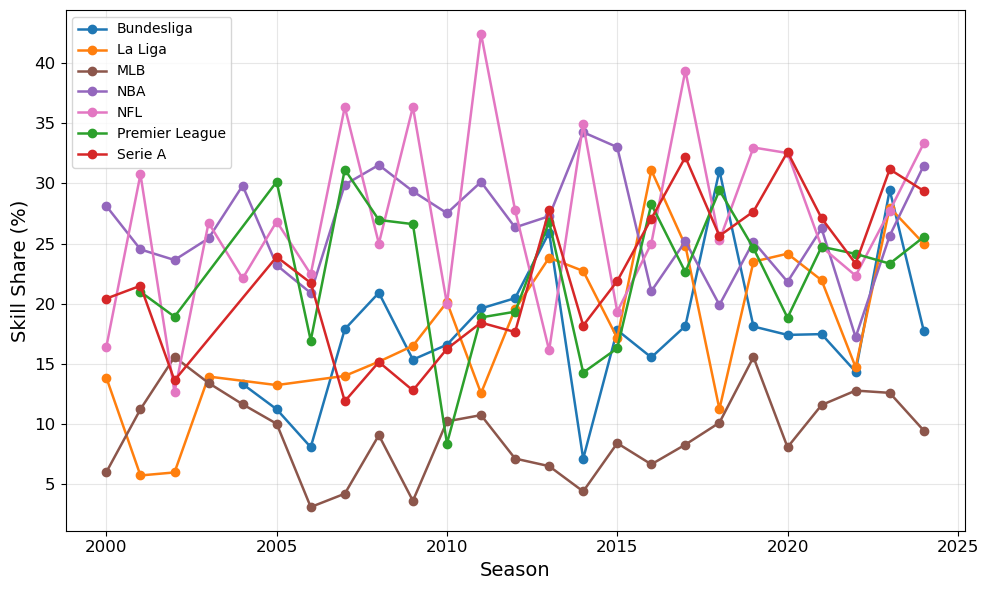

In [13]:
fig = plt.figure(figsize=(10, 6))

for league in sorted(all_upset["league"].unique()):
    df_league = all_upset[all_upset["league"] == league].sort_values("season")
    plt.plot(
        df_league["season"],
        df_league["skill_share_pct"],
        marker="o",
        linewidth=1.8,
        label=league,
        color=color_map.get(league, None),
    )

plt.xlabel("Season", fontsize=14)
plt.ylabel("Skill Share (%)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

out = here / "year_on_year_upset_frequency_skill_luck_share.png"
fig.savefig(out, dpi=300)
print(f"Saved figure to: {out}")

plt.show()